# import Module

In [40]:
import torch.nn as nn
from imblearn.over_sampling import  SMOTE
import torch
import pandas as pd 
import numpy as np  
import copy
import pickle
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset , DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report , accuracy_score , recall_score , precision_score , roc_auc_score , confusion_matrix

# Dataset 

In [32]:
df  = pd.read_csv(".\\Customer-Churn-Records.csv")
print(df.head(5), "\n\n")

x_num = df[["CreditScore" , "Age" , "Tenure", "Balance", "NumOfProducts" , "HasCrCard", "IsActiveMember", "EstimatedSalary"]]
x_text = df[["Geography" , "Gender"]]
y = df["Exited"]
print(y.value_counts() , ">>>>the biggest problem\n\n")

ohe = OneHotEncoder(sparse_output=False)
x_text = ohe.fit_transform(x_text)

x = np.concatenate([x_num , x_text], axis=1)
x = np.array(x)
y = np.array(y)

scaler = StandardScaler()
x = scaler.fit_transform(x)

smote = SMOTE(random_state=42)
x_res , y_res = smote.fit_resample(x , y)

X_train , X_temp , Y_train , Y_temp = train_test_split(x_res , y_res , test_size=0.2)
X_test , X_val , Y_test , Y_val = train_test_split(X_temp , Y_temp , test_size=0.5)
X_train.shape , X_test.shape , X_val.shape , Y_train.shape

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

((12739, 13), (1592, 13), (1593, 13), (12739,))

In [10]:
from sklearn.ensemble import GradientBoostingClassifier as skl_GBC
feature_importance = skl_GBC(max_depth=7,min_samples_split=3 , random_state=42)
feature_importance.fit(X_train , Y_train)
feature = feature_importance.feature_importances_

for i ,f in enumerate(feature):
    print(f"{i} score : {f}")


print(df[0:10])

0 score : 0.027925249604546835
1 score : 0.44764163698839476
2 score : 0.06953603657157781
3 score : 0.1007557778198455
4 score : 0.2106639902362674
5 score : 0.0037308510180606423
6 score : 0.054777211235359516
7 score : 0.040565204121425925
8 score : 0.00373043844514379
9 score : 0.023746590288224307
10 score : 0.0036836561422446228
11 score : 0.009052599896158132
12 score : 0.00419075763275069
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   
5          6    15574012       Chu          645     Spain    Male   44   
6          7    15592531  Bartlett          822    France    Male   50   
7       

In [11]:
ds_train_tensor = TensorDataset(torch.tensor(X_train, dtype=torch.float32) , torch.tensor(Y_train, dtype=torch.float32))
ds_val_tensor = TensorDataset(torch.tensor(X_val, dtype=torch.float32) , torch.tensor(Y_val, dtype=torch.float32))

ds_train = DataLoader(ds_train_tensor , batch_size=400 , shuffle=True)
ds_val = DataLoader(ds_val_tensor , batch_size=400 , shuffle=False)

# Model

In [33]:
input_dim = X_train.shape[1]
model = nn.Sequential(
    nn.Linear(input_dim , 256) , nn.ReLU(),
        nn.Linear(256, 128) , nn.ReLU() , 
    nn.Linear(128, 64) , nn.ReLU() , 
    nn.Linear(64 , 32 ) , nn.ReLU() , 
    nn.Dropout(0.8),
    nn.Linear(32, 1),
    nn.Sigmoid()
)

# Train

In [34]:
criterion = nn.BCELoss() 

optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',patience=20,  factor=0.4, min_lr=1e-3)

epochs = 100
patience = 20
best_val_loss = float('inf')
best_weights = copy.deepcopy(model.state_dict())
patience_counter = 0

history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

for epoch in range(epochs):
    model.train()
    train_loss, train_correct = 0.0, 0
    for X_batch, y_batch in ds_train:
        optimizer.zero_grad()
        outputs = model(X_batch).squeeze(1)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * X_batch.size(0)
        preds = (outputs > 0.5).float()
        train_correct += (preds == y_batch).sum().item()
        
    train_loss /= len(ds_train.dataset)
    train_acc = train_correct / len(ds_train.dataset)

    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for X_batch_val, y_batch in ds_val:
            outputs = model(X_batch_val).squeeze(1)
            loss = criterion(outputs, y_batch)
            
            val_loss += loss.item() * X_batch_val.size(0)
            preds = (outputs > 0.5).float()
            val_correct += (preds == y_batch).sum().item()
            
    val_loss /= len(ds_val.dataset)
    val_acc = val_correct / len(ds_val.dataset)
    
    scheduler.step(val_loss)

    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break
            
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} - loss: {train_loss:.4f} - acc: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")
model.load_state_dict(best_weights)

Epoch  10/100 - loss: 0.4267 - acc: 0.8121 - val_loss: 0.4327 - val_acc: 0.7966
Epoch  20/100 - loss: 0.3439 - acc: 0.8543 - val_loss: 0.3922 - val_acc: 0.8299
Epoch  30/100 - loss: 0.2931 - acc: 0.8827 - val_loss: 0.3950 - val_acc: 0.8475
Epoch  40/100 - loss: 0.2427 - acc: 0.9061 - val_loss: 0.3975 - val_acc: 0.8562
Epoch  50/100 - loss: 0.1967 - acc: 0.9268 - val_loss: 0.4496 - val_acc: 0.8519

Early stopping triggered at epoch 52


<All keys matched successfully>

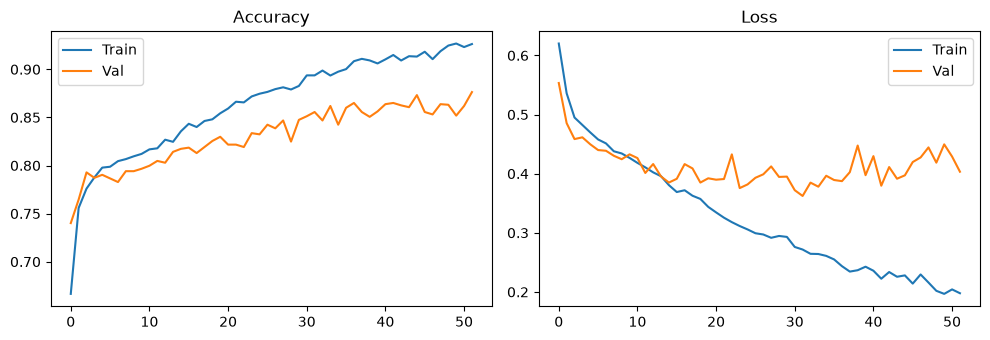

In [35]:
plt.figure(figsize=(10, 3.5))
plt.subplot(1, 2, 1)
plt.plot(history["accuracy"]); plt.plot(history["val_accuracy"])
plt.title("Accuracy"); plt.legend(["Train", "Val"])

plt.subplot(1, 2, 2)
plt.plot(history["loss"]); plt.plot(history["val_loss"])
plt.title("Loss"); plt.legend(["Train", "Val"])
plt.tight_layout(); plt.show()

# Test 

In [36]:
model.eval()
with torch.no_grad():
    X_test = torch.tensor(X_test , dtype=torch.float32)
    y_prob = model(X_test).squeeze(1).numpy()

y_pred = (y_prob > 0.5).astype(int)

acc = accuracy_score(Y_test, y_pred)
prec = precision_score(Y_test, y_pred)
rec = recall_score(Y_test, y_pred)
f1 = roc_auc_score(Y_test, y_pred)

print(f"Accuracy: {acc:.4f}  Roc_Auc_Score: {f1:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}")
print(confusion_matrix(Y_test, y_pred))
print(classification_report(Y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))


Accuracy: 0.8957  Roc_Auc_Score: 0.8964  Precision: 0.8463  Recall: 0.9645
[[666 138]
 [ 28 760]]
              precision    recall  f1-score   support

 No Diabetes       0.96      0.83      0.89       804
    Diabetes       0.85      0.96      0.90       788

    accuracy                           0.90      1592
   macro avg       0.90      0.90      0.90      1592
weighted avg       0.90      0.90      0.90      1592



In [41]:
torch.save(model.state_dict(), "model_bank_costumers.pt")

with open("model_bank_costumers.pkl" , "wb") as f:
    pickle.dump(model ,f )

with open("OneHotEncoder.pkl" , "wb") as f:
    pickle.dump(ohe ,f )

with open("StandardScaler.pkl" , "wb") as f:
    pickle.dump(scaler ,f )

with open("SMOTE.pkl", "wb") as f:
    pickle.dump(smote , f)